In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from itertools import product, combinations

In [ ]:
RndmGraph = nx.random_geometric_graph(7, 1, dim=2, seed=42)
#RndmGraph = nx.barabasi_albert_graph(6, 1)

In [ ]:
G = nx.Graph(RndmGraph) #creates graph copy
print(list(G.nodes()))

mappingT = {i:("T", i)for i in G.nodes()} # map T to Terminals
G = nx.relabel_nodes(G, mappingT)         


TerminalArray = list(G.nodes()) 
TerminalArrayLength = len(TerminalArray)

print(f"TerminalArray: {TerminalArray}")
print(f"TerminalArrayLength: {TerminalArrayLength}")


In [ ]:
#UNUSED first idea for creating a list of all Topos was scraped 
# as i coulndt find a good way to generate all "full" Steiner topologies for a Graph with Terminals

i=0
while i < TerminalArrayLength:   #with = its of by 1 error!
    if (TerminalArrayLength % 2 == 0):
        print(i)
        i += 1
    else:
        print("odd",i)
        print("odd",TerminalArray[i])
        i += 1


In [ ]:
#OUTPUT node pos/coords, edges etc.
#  G.nodes[0]
# G.edges()
# G.edges[0, 1]

node = list(G.nodes)[0]
print(f"Node: {node}")
print(G.nodes[node])

edge=list(G.edges)[0]
print(f"Edge: {edge}")
print(G.edges[edge])

In [ ]:
    #VIS plot graph (w/o steiner points)
pos = nx.get_node_attributes(G, "pos") # works only with generated geo graphs or pos added to nodes

nx.draw(G, pos, with_labels=True)
plt.show()

In [ ]:
#TOPO algorithm

#find all full Steiner topos. (Terminals degree 1, All Steiner points degree 3, tree = n-2 Steiner points))
#Labeling: ("T", i) for terminals, ("S", j) for Steiner points

def FullSteinerTopologies(TerminalArray):
    n = len(TerminalArray) #amount of terminals

    #if less then 3 terminals, no Steiner point possible
    if n < 3:                                 
        Start = nx.Graph()
        Start.add_nodes_from(TerminalArray)
        if n == 2:
            Start.add_edge(TerminalArray[0], TerminalArray[1])
        return [Start]


    # connect first 3 terminals to S0 point
    Start = nx.Graph()
    Start.add_edges_from([(TerminalArray[k], ("S", 0)) for k in range(3)])
    Topologies = [Start]

    # insert every new terminal into every edge of every topology found so far:
    # cut the edge put a new Steiner point in the middle and  hang the new terminal on it
    for k in range(3, n):
        Grown = [] # start with an empty list for the new topologies
        for T in Topologies:
            for (u, v) in T.edges():    # loop over all edges (u, v) in previous topology T
                New = T.copy()                # copy the topology T to a new graph New
                S = ("S", k - 2)              # add ne steiner point (k -2 because first 3 terminals are connected to S0)
                New.remove_edge(u, v)         # remove the replaced edge 
                New.add_edges_from([(u, S), (S, v), (S, TerminalArray[k])]) # add new edges for new steiner point and terminal
                Grown.append(New)
       
        Topologies = Grown
    return Topologies

In [ ]:
#algorithm execution and output
Topologies = FullSteinerTopologies(TerminalArray)
n = len(TerminalArray)
edges = Topologies[0].edges()
AllEdgeTopos = [T.edges() for T in Topologies]

print("All Edge Topos:")
for T in Topologies:
    print(f"Topo: {Topologies.index(T)}", " "
        .join(
        f"({u[0]}{u[1]}-{v[0]}{v[1]})"
        for u, v in T.edges()
        )
)

expected = 1
for f in range(1, 2 * n - 4, 2):
    expected *= f

print("Edges ", list(Topologies[0].edges()))
print("terminals ", n)
print("topologies:", len(Topologies), "expected:", expected)

In [ ]:
# check all topology shapes, postion of terminals and Steiner points not representative
if n >= 3:
    for T in Topologies:
        SteinerPoints = [v for v in T.nodes() if v[0] == "S"]
        assert nx.is_tree(T)
        assert len(SteinerPoints) == n - 2
        assert len(T.edges()) == 2 * n - 3
        assert all(T.degree(t) == 1 for t in TerminalArray)      
        assert all(T.degree(s) == 3 for s in SteinerPoints)      
    print("Topologies check passed")


#Draw topologies
Columns = 5
Rows = int(np.ceil(len(Topologies) / Columns))
fig, axes = plt.subplots(Rows, Columns, figsize=(2 * Columns, 2 * Rows))

#labels and colors for graphs
for ax, T in zip(np.ravel(axes), Topologies):
    Labels = {v: (v[1] if v[0] == "T" else "") for v in T.nodes()}
    Colors = ["tab:orange" if v[0] == "T" else "tab:blue" for v in T.nodes()]
    nx.draw(T, nx.spring_layout(T, seed=42), ax=ax,
            labels=Labels, node_color=Colors, node_size=80, font_size=6, font_color="white")

plt.show()

## Next steps
* generate "not" full steiner trees 
* get all indvidual edge lengths (using pos)
* add up all edge lengths for each topo
* find shortest one

##### new
* best non-full steiner tree is degenarted version of best full steiner tree
* indv. edge lengths makes no sense but, we could first calculate the possible steiner pos. fromn the Topo (so if S1-A-B-C is used multiple times we dont have to calculate it all the time)
* schwierig steiner knoten pos. bestimmen bei veeb. zu anderen steinerknoten wobei-> bei zwei gegebenen punkten gibt es ja in der 120 grad regel nur noch zwei optinon

------

#### trying to implement hwang/melzak for now



In [ ]:
#MELZAK algorithm:
# for every Steiner point s we are building a equilateral triangle with its two known neighbors a and b resulting in a new point e (2 possible postions for each e),
# e is then connected to c (third neighbor of s with unknown position) and a,b are removed, repeat until only one edge is left
# -> the last remaining edge has the same length as the whole tree
# to check if we get valid steinerpoints we go backwards through the algorithm and place steiner points 
# on the e-c edge where it intersects with a circle through a, b, e


#find the position of the equilateral point ( a, b, side -1 or +1 for left and right side placement)
def EquilateralPointPosition(a, b, side):
    angle = side * np.pi / 3.     
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    return a + R @ (b - a)

#find posible Steiner point position from where the circle(a, b, e) intersects with the edge e-c
def SteinerPointCircleEdgeIntersect(a, b, e, c):
    O = (a + b + e) / 3                   # center of the triangle
    d = (c - e) / np.linalg.norm(c - e)   # direction e->c
    t = -2 * np.dot(e - O, d)             # distance from e to second intersection
    s = e + t * d

    # return S if it lies on e-c edge and sector angles(S-a-b) are under 120 degrees 
    if t <= 1e-9 or t > np.linalg.norm(c - e) + 1e-9:
        return None
    sa = a - s
    sb = b - s
    cosAngle = np.dot(sa, sb) / (np.linalg.norm(sa) * np.linalg.norm(sb)) #find angle between a-s-b (sa and sb edges)
    if abs(cosAngle - np.cos(2 * np.pi / 3)) > 1e-6:
        return None
    return s

#search for steiner points s with two known neighbors, needed for triangle building
def FindSteinerPoint(Tree, Points):
    for s in Tree.nodes():
        if s[0] != "S":     #filter out terminals
            continue
        KnownPoints = [v for v in Tree.neighbors(s) if v in Points] # points should only contain terminals (with known postions)
        if len(KnownPoints) >= 2:
            a = KnownPoints[0]
            b = KnownPoints[1]
            c = [v for v in Tree.neighbors(s) if v != a and v != b][0]
            return s, a, b, c


#this creates a list only containing the terminal postions (known positions), i.e. remove steiner points
TerminalPos = {t: np.array(p) for t, p in nx.get_node_attributes(G, "pos").items()}

def Melzak(T, Sides): # returns (length, SteinerPositions) or None if topology is not realizable with these sides
    Tree = T.copy()
    Points = dict(TerminalPos)
    Steps = []  # remember every replacement, to undo them later in reverse order to find Steiner points

    # 1st. remove one Steiner point per step until only one edge is left
    while Tree.number_of_edges() > 1:
        s, a, b, c = FindSteinerPoint(Tree, Points)
        E = ("E", s[1])
        Points[E] = EquilateralPointPosition(Points[a], Points[b], Sides[s]) #add point E to points dict
        Tree.remove_nodes_from([a, b, s])   # remove a, b, s points
        Tree.add_edge(E, c)                 # connect new point E to c
        Steps.append((s, a, b, c, E))

    # the last edge has the same length as the whole tree
    (u, v), = Tree.edges()
    length = np.linalg.norm(Points[u] - Points[v])

    # 2nd. undo the steps in reverse, find steinerpoints and if this is a valid topology
    for s, a, b, c, E in reversed(Steps):
        sPos = SteinerPointCircleEdgeIntersect(Points[a], Points[b], Points[E], Points[c])
        if sPos is None:
            return None
        Points[s] = sPos

    SteinerPos = {s: Points[s] for s in T.nodes() if s[0] == "S"}
    return length, SteinerPos


#run Melzak on all topologies of the given terminals, keep the shortest valid tree
def BestFullTree(Terminals):
    BestLength, BestTopo, BestSteinerPos = np.inf, None, None
    ValidTopos = 0

    for T in FullSteinerTopologies(Terminals):
        SteinerPoints = [v for v in T.nodes() if v[0] == "S"] # extract steiner points from topology
        Valid = False
        for TriangleChoice in product((+1, -1), repeat=len(SteinerPoints)): # e point can be on both sides of a-b -> try +1/-1 for every Steiner point
            Result = Melzak(T, dict(zip(SteinerPoints, TriangleChoice))) # this matches the steinerpoints with side choices determined by product(...)
            if Result is None:
                continue
            Valid = True
            length, SteinerPos = Result #if valid get length from result
            if length < BestLength:
                BestLength, BestTopo, BestSteinerPos = length, T, SteinerPos
        if Valid:
            ValidTopos += 1
    return BestLength, BestTopo, BestSteinerPos, ValidTopos

valid full topologies: 3 of 945
best full Steiner tree length: 2.1946


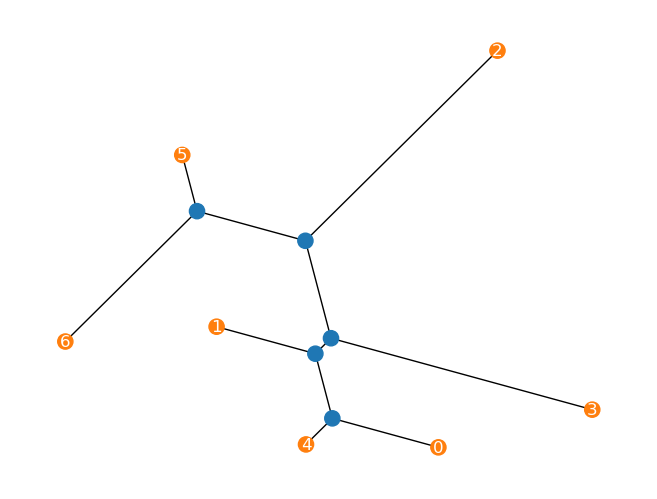

optimal Steiner tree length: 1.7761
full parts: 4


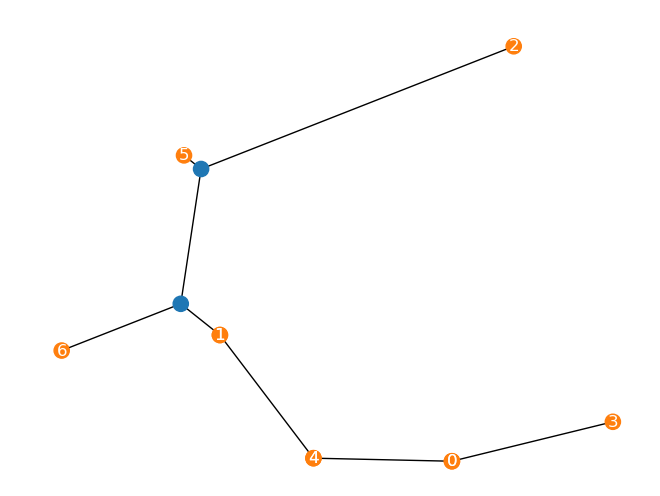

In [33]:
# Find best full non-full steiner trees using melzak
# "full" finds best full Steiner tree, "optimal" finds also the shortest non-full Steiner tree
#Explanation:
# splitting a non full steiner tree results into smaller full Steiner trees 
# -> best tree could be the full tree over X (Melzak) or best(A) + best(B) (A and B sharing exactly one terminal t)
# start with small subsets and go up to all terminals, so bigger subsets can reuse the results of the smaller ones

Mode = "optimal" 
 
AllTerminals = frozenset(TerminalArray) #example-TerminalArray: [('T', 0), ('T', 1), ('T', 2), ('T', 3), ('T', 4), ('T', 5), ('T', 6)]

#find best full tree 
FullLength, FullTopo, FullSteinerPos, ValidTopos = BestFullTree(TerminalArray)


if Mode == "optimal":
    Best = {}   # contains the best Steiner tree for each subset of terminals
    for k in range(2, len(TerminalArray) + 1): 
        for Subset in combinations(TerminalArray, k): # builds all subsets of terminals (from TerminalArray) with size k 
            X = frozenset(Subset)                     #basically starting from the bottom  of the tree and going up to the full tree with all terminals
            length, Topo, SteinerPos, _ = BestFullTree(list(Subset))  #for each subset of terminals find the best full Steiner tree
            Best[X] = (length, [(Topo, SteinerPos)]) #saves the best full steiner tree (if it exists) for the subsets (inc. topo and length)

            # this loop checks the subset X and if its possible to build the subset out of other subsets
            # and if the result of the then joined subsets is smalle than the full graph
            for t in X: # iterate over each terminal as possible split point in the subset                 
                Rest = sorted(X - {t}) #removes splitpoint from set
                for size in range(1, len(Rest)): 
                    for Part in combinations(Rest, size): # build all combinations of possible subsets
                        A = frozenset(Part) | {t}
                        B = X - frozenset(Part)
                        if Best[A][0] + Best[B][0] < Best[X][0]:
                            Best[X] = (Best[A][0] + Best[B][0], Best[A][1] + Best[B][1]) 
                            #if any graph built with subsets is shorter than the full one overwrite it
                            # repeat until "complete" graph" is reached



####OUTPUT

#Plotting
def DrawParts(Parts):
    for Topo, SteinerPos in Parts:
        Colors = ["tab:orange" if v[0] == "T" else "tab:blue" for v in Topo.nodes()]
        Labels = {v: (v[1] if v[0] == "T" else "") for v in Topo.nodes()}
        nx.draw(Topo, {**TerminalPos, **SteinerPos}, labels=Labels, node_color=Colors, node_size=120, font_color="white")
    plt.gca().set_aspect("equal")
    plt.show()


#Full output - allways
print(f"valid full topologies: {ValidTopos} of {len(Topologies)}")
if FullTopo is None:
    print("no valid full Steiner tree")
else:
    print(f"best full Steiner tree length: {FullLength:.4f}")
    DrawParts([(FullTopo, FullSteinerPos)])

#Optimal output
if Mode == "optimal":
    OptLength, OptParts = Best[AllTerminals]
    print(f"optimal Steiner tree length: {OptLength:.4f}")
    print(f"full parts: {len(OptParts)}")
    DrawParts(OptParts)
